## 1. Business Understanding

### Objetivo
- Analizar los registros de personas desaparecidas para identificar patrones relevantes que pueden apoyar la comprensión del fenómeno de las desapariciones.

### Preguntas de análisis
- ¿En qué entidades hay más desapariciones?
- ¿Qué años han registrado más casos?
- ¿Cómo evolucionan las desapariciones en el tiempo?
- ¿Se observan concentraciones por periodos específicos?

### Criterios de éxito
- Identificación clara de tendencias temporales y geográficas  
- Detección de posibles zonas críticas  
- Resultados interpretables  

---

## 2. Data Understanding

### Exploración inicial
Con base en el dataset podemos definir que las variables más relevantes para la obtención de la información que responda a las preguntas planteadas para el análisis son:

- `entidad_desap`
- `fecha_desap`
- `estatus_busqueda`
- `nombrecompleto`

Variables técnicas o redundantes (`bg_1`, `bg_2`, `rnpdno_csv`) probablemente no son útiles para este fin.

### Evaluación de calidad
Se debe revisar:

- Valores faltantes (especialmente en fechas o entidad)  
- Formato de fechas (`fecha_desap` está como string, por lo tanto necesita conversión)  
- Duplicados (posibles registros repetidos)  
- Inconsistencias en categorías (ej: estados escritos de manera diferente)  

### Hipótesis preliminares
- Algunas entidades concentran la mayoría de casos  
- Hay aumento de desapariciones en años recientes  

---

## 3. Data Preparation

### Limpieza
- Eliminar columnas irrelevantes (`Unnamed: 0`, `bg_1`, `bg_2`, `rndpo`, etc.)  
- Manejo de nulos (eliminar o imputar según relevancia)  

### Transformación
- Convertir `fecha_desap` a formato `datetime`  
- Extraer: Año, Mes, Día  

---

## 4. Selección de variables

### Variables clave
- `entidad_desap`  
- `fecha_desap`  
- `estatus_busqueda`  

### Variables derivadas
- `anio_desap`  

---

## 5. Modelling
(Pendiente)

---

## 6. Evaluation

### Validación de hallazgos
- Comparar con fuentes externas  
- Verificar consistencia interna (tendencias lógicas)  

### Sesgos y limitaciones
- Subregistro de desapariciones  
- Datos incompletos o inconsistentes  

### Criterios de utilidad
- Claridad para tomar decisiones  
- Capacidad de replicación del análisis  

---

## 7. Deployment

### Entrega del análisis
- Reporte de hallazgos clave con gráficas que lo respalden  
- Conclusiones  

### Notebook
- Código reproducible en Python  

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Cargar datos
# -------------------------------
df = pd.read_csv("tot_reg_desap.csv")

# -------------------------------
# Nuevo dataset con columnas clave 
# -------------------------------
df_reducido = df[["nombrecompleto", "entidad_desap", "estatus_busqueda", "fecha_desap"]]

# -------------------------------
# Preparación de datos
# -------------------------------

# Convertir fecha
df_reducido["fecha_desap"] = df_reducido["fecha_desap"].str.split(",").str[0]
df_reducido["fecha_desap"] = pd.to_datetime(df_reducido["fecha_desap"], dayfirst=True, errors="coerce")
df_reducido["anio_desap"] = df_reducido["fecha_desap"].dt.year
#df_reducido = df_reducido.drop(columns=["fecha_desap"])

# Buscando registros duplicados
#duplicados = df_reducido[df_reducido.duplicated()]
duplicados = df_reducido[df_reducido.duplicated()]

print(duplicados)

# Eliminar aquellos duplicados que tengan los 4 campos iguales (nombre, entidad, estatus, fecha)
df_reducido = df_reducido.drop_duplicates(subset=[
    'nombrecompleto',
    'entidad_desap',
    'estatus_busqueda',
    'fecha_desap'
])

duplicados = df_reducido[df_reducido.duplicated()]
print(duplicados)

# Mostrando nuevo dataset
#df_reducido.head()

                        nombrecompleto    entidad_desap  \
167       ADRIAN MARTIN SANCHEZ CERDAS        QUERETARO   
218                 RUBEN MONROY ACUÑA        QUERETARO   
570              J JESUS ESTRADA MEJIA        QUERETARO   
626    MARIA GUADALUPE SERRANO AGUILAR        QUERETARO   
694             FEDERICO FLORES CORTES        QUERETARO   
...                                ...              ...   
88710    CRESCENCIO SALVADOR HERNANDEZ  SAN LUIS POTOSI   
88711    CRESCENCIO SALVADOR HERNANDEZ  SAN LUIS POTOSI   
88785                CRISTIAN MARTINEZ  SAN LUIS POTOSI   
89431            EMMANUEL PEREZ CORTES          NAYARIT   
89623           LUIS ANGEL BERNAL PAEZ          NAYARIT   

                                        estatus_busqueda fecha_desap  \
167                                  Se busca reportante  2021-06-08   
218                                  Se busca reportante  2018-05-10   
570                                                  NaN  2003-12-26   
626

Para empezar el análisis de los datos primero reducimos el dataset para trabajar con las columnas de las que se obtendrá la información para poder responder a las preguntas planteadas en el Business Understanding, en este caso será el nombre completo, la entidad de desaparición, el estatus de la búsqueda y la fecha de desaparición.

Como pudimos ver en la exploración del dataset, la fecha es un String por lo que se aplicó una transformación a un tipo de dato datetime que nos puede ayudar a manipular la fecha por dia, mes y año (necesario para hacer el análisis de los años). Además de agregar la columna año que nos servirá para analizar tendencias de desapariciones por año más adelante.

Posteriormente para limpiar el dataset partimos de la idea de qué hacer con los campos nulos y entradas duplicadas. En nuestro caso imprimimos las entradas duplicadas del dataset y notamos que hay casos en los que hay datos nulos como la falta del nombre o la fecha de desaparición. Para decidir qué hacer con estos valores pensamos lo siguiente.

1. Que las entradas con TODOS los campos iguales se pueden eliminar sin problema porque puede ser el caso de la misma persona
2. Que las entradas con algún campo diferente puede ser un caso distinto

Así que metimos una función drop para bajar todas las entradas donde los campos sean exactamente el mismo, para dejar un dataset con la menor cantidad de casos duplicados posibles.

Como se puede ver en la primera salida, había 599 registros duplicados. Pero al aplicar el drop esto se redujo a un dataframe vacio.

In [28]:
# contar frecuencia de cada variable del dataset reducido

columnas_interes = [
    'entidad_desap',
    'estatus_busqueda',
    'anio_desap'
]

# Imprimimos esto para visualización
for col in columnas_interes:
    print(f"\nFrecuencia de {col}:")
    print(df_reducido[col].value_counts(dropna=False, sort=False))

#guardamos las frecuencias de los posibles valores de las variables en un diccionario para su posterior uso
frecuencias = {}

for col in ['entidad_desap', 'estatus_busqueda', 'anio_desap']:
    frecuencias[col] = df_reducido[col].value_counts(dropna=False, sort=False)

#Muestra de ejemplo de persona con multiple registro y variación de algún parámetro
df_reducido[df_reducido['nombrecompleto'] == 'SERGIO SIMONS CARRILLO']


Frecuencia de entidad_desap:
entidad_desap
QUERETARO                707
CHIHUAHUA               4130
DURANGO                  733
COAHUILA                3081
MICHOACAN               5072
NUEVO LEON              4607
JALISCO                 4692
HIDALGO                  716
GUERRERO                4069
SE DESCONOCE            2710
TAMAULIPAS             11786
COLIMA                  1232
AGUASCALIENTES           409
CIUDAD DE MEXICO        3833
GUANAJUATO              2056
ESTADO DE MEXICO       10935
VERACRUZ                5965
SINALOA                 5366
BAJA CALIFORNIA         1994
QUINTANA ROO             632
SONORA                  4324
ZACATECAS               2467
BAJA CALIFORNIA SUR      599
PUEBLA                  2502
MORELOS                 1179
OAXACA                   434
CAMPECHE                  72
YUCATAN                  173
TABASCO                  199
CHIAPAS                  889
SAN LUIS POTOSI          748
NAYARIT                  755
TLAXCALA                  66

,nombrecompleto,entidad_desap,estatus_busqueda,fecha_desap,anio_desap
19320,SERGIO SIMONS CARRILLO,JALISCO,Denuncia confirmada,1973-07-15,1973.0
19935,SERGIO SIMONS CARRILLO,JALISCO,Denuncia confirmada,1973-07-24,1973.0
29329,SERGIO SIMONS CARRILLO,SE DESCONOCE,Denuncia confirmada,1973-07-15,1973.0
45844,SERGIO SIMONS CARRILLO,CIUDAD DE MEXICO,NaN,1973-07-15,1973.0


En esta segunda pasada, a pesar de que tratamos de reducir lo más posible los casos de registros repetidos, hay algunos casos que permanecen en el dataset. Por ejemplo el caso de Sergio Simons Carrillo que está registrado 4 veces, pero su entidad de desaparición difiere en distintos registros, de igual manera el estatus y la fecha. Para estos casos lo mejor en nuestra consideración es dejarlos porque puede ser algún caso de posibles homónimos (aunque a simple vista no lo parezca), además de que hay registros sin nombre que pueden ser personas disntintas reportadas en la misma fecha o con el mismo estatus de búsqueda.

De igual manera se procedió en hacer el conteo de frecuencia de los distintos valores que pueden adoptar las variables elegidas, lo cual nos puede servir para calcular medidas de interés como las medidas de localización, de variabilidad, de heterogeneidad.

3. Calculo de medidas con visualizaciones e interpretación

-> Medidas de localización: ¿en qué región de valores tiende a concentrarse el fenómeno observado?
 * Media
 * Mediana
 * Moda

La media de desapariciones por entidad es: 2700.969696969697
La media de desapariciones por anio es: 1417.5689655172414
La mediana de los anios del dataset es: 2016.0
La moda de los anios del dataset es: 0    2007.0
Name: anio_desap, dtype: float64
La moda de los estados del dataset es: 0    TAMAULIPAS
Name: entidad_desap, dtype: str
La moda de los estados de busqueda del dataset es: 0    Se busca reportante
Name: estatus_busqueda, dtype: str


<Figure size 1800x500 with 0 Axes>

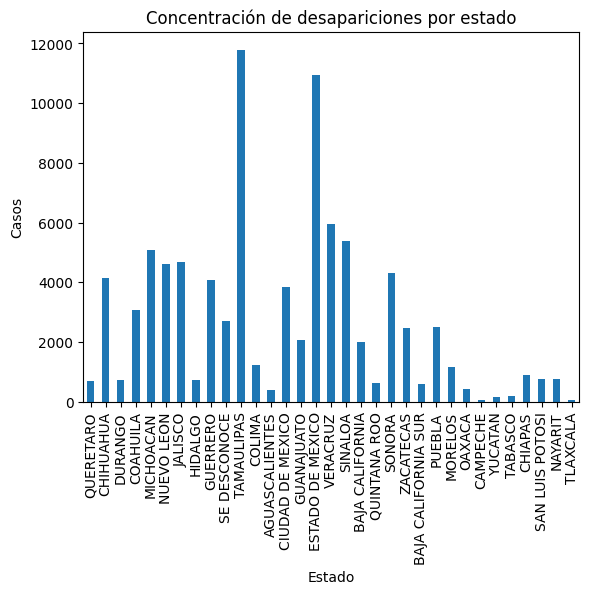

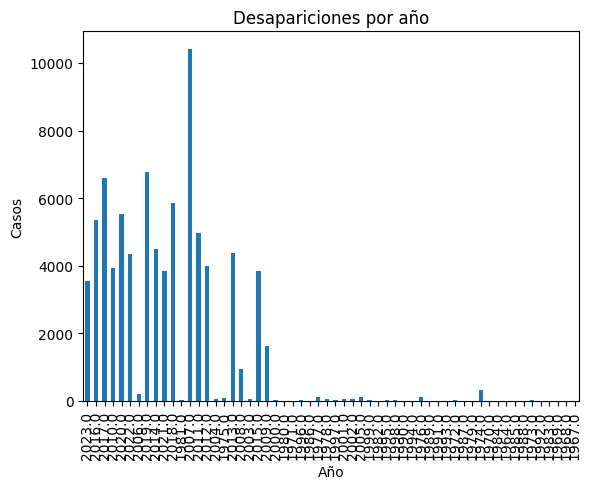

In [32]:
frecuencias_entidad = df_reducido['entidad_desap'].value_counts(sort=False)
frecuencias_anio = df_reducido['anio_desap'].value_counts(sort=False)
frecuencias_estatus = df_reducido['estatus_busqueda'].value_counts(sort=False)

media_entidades = frecuencias_entidad.mean()
print("La media de desapariciones por entidad es: " + str(media_entidades))

media_anual = frecuencias_anio.mean()
print("La media de desapariciones por anio es: " + str(media_anual))

mediana_anio = df_reducido['anio_desap'].median()
print("La mediana de los anios del dataset es: " + str(mediana_anio))

moda_anio = df_reducido['anio_desap'].mode()
print("La moda de los anios del dataset es: " + str(moda_anio))

moda_estado = df_reducido['entidad_desap'].mode()
print("La moda de los estados del dataset es: " + str(moda_estado))

moda_estatus = df_reducido['estatus_busqueda'].mode()
print("La moda de los estados de busqueda del dataset es: " + str(moda_estatus))
#####################################
# Graficas medidas de localización
#####################################

# Crear figura
plt.figure(figsize=(18, 5))

# -----------------------
# Estados
# -----------------------
plt.figure()
frecuencias_entidad.plot(kind='bar')  
plt.title('Concentración de desapariciones por estado')
plt.xlabel('Estado')
plt.ylabel('Casos')
plt.xticks(rotation=90)
plt.show()

# -----------------------
# Años
# -----------------------
plt.figure()
frecuencias_anio.plot(kind='bar')
plt.title('Desapariciones por año')
plt.xlabel('Año')
plt.ylabel('Casos')
plt.xticks(rotation=90)
plt.show()



De las medidas de localización de las variables analizadas podemos obtener la siguiente información:

* Dado que la media de desapariciones es de aproximadamente 2700, esto quiere decir que si las desapariciones estuvieran distribuidas de manera uniforme, cada estado tendría esa cantidad de desaparecidos. Pero la realidad es que hay algunos estados que están muy por arriba de la media y otros muy por debajo. Un análisis interesante que se podría hacer es sacar una relación entre la cantidad de desapariciones y la cantidad de habitantes que hay en cada entidad, lo cual nos podría dar una información más tangible sobre la verdadera situación de inseguridad de cada entidad.
  
* La media de desapariciones por año es de aproximadamente 1417. Esto nos indica que si la cantidad de desaparecidos por año estuviera repartida de manera uniforme habría dicha cantidad cada año. Pero igual que el caso anterior hay años que concentran muy poco porcentaje del total de desaparecidos y años que concentran gran parte.

* No se puede obtener la mediana de las variables entidad_desap y estatus_busqueda debido a que son de tipo categorico (no numérico)

* El hecho de que la mediana de los años sea el año 2016 indica que en ese año está la mitad de las desapariciones. Es decir que es un punto de partida donde el 50% de las desapariciones se encuentran entre los años 1964 a 2016 y el otro 50% de las desapariciones se encuentran entre 2016 y 2023. Lo cual indica un dato alarmante, ya que te dice mucho de cómo se ha disparado la inseguridad en México en los úlitmos años.

* Que la moda de los años sea 2007 indica que ese año fue en el que más desapariciones se registraron

* Que la moda de los estados sea Tamaulipas indica que ese es el estado más inseguro o en el que más desapariciones se registran

* Que la moda de los estados de busqueda sea "se busca reportante" indica que la mayoría de las desapariciones no han sido reportadas

* Gracias a las gráficas podemos confirmar la información deducida anteriormente

In [ ]:
-> Medidas de variabilidad: ¿qué tan separados o concentrados están los datos alrededor de ese centro?
 * Rango
 * Varianza muestral
 * Desviación estándar
 * Recorrido intercuartílico
 * Coeficiente de variación
   
-> Medidas de heterogeneidad: ¿el comportamiento observado es homogéneo en toda la población o cambia de manera importante entre grupos?
 * Indice de Gini

-> Medidas de concentración: ¿cómo se reparte el total entre las unidades que componen el sistema?
 * 